In [ ]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Input,
    Concatenate,
    Dropout,
    LeakyReLU,
    BatchNormalization,
)
from keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from keras import ops

from google.colab import drive

Firstly, we load the data, convert the pixels of puctires `(X)` to be between 0-1 for better model performance and one-hot encode the labels `(y)`:

In [ ]:
drive.mount('/content/drive')

X = np.load("/content/drive/MyDrive/Assignment_2/data/x_letters.npy")
y = np.load("/content/drive/MyDrive/Assignment_2/data/y_letters.npy")

num_classes = 26

X_train = X / 255.0

y_train = to_categorical(y, num_classes=num_classes)  # One-hot encode labels,

Mounted at /content/drive


Next, we check how the data is structured, if the data would have same instances after each other, it would make sense to shuffle it, but since we can see that the data are random already, there is no need for that.

In [ ]:
def number_to_letter(number):
    if 0 <= number <= 25:
        return chr(number + 65)  # ASCII value of 'A' is 65, so we add 65 to the number.
    else:
        return None

for i in range(10):
    print(number_to_letter(y[i]))

G
P
O
W
Q
M
K
V
X
J


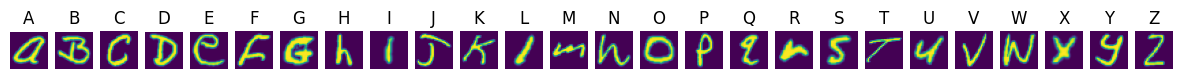

In [ ]:
def getLabelName(image):
    return np.argmax(image)


def plot_samples_by_label(X, y):
    fig, axes = plt.subplots(1, num_classes, figsize=(15, 15))
    plotted_labels = set()

    for i in range(len(y)):
        label = getLabelName(y[i])  # Get the label index
        if label not in plotted_labels:
            # Plot only one example per label
            ax = axes[label]
            ax.imshow(X[i])
            ax.set_title(chr(label + 1 + 64))
            ax.axis("off")
            plotted_labels.add(label)

        # Stop once we have examples for all labels
        if len(plotted_labels) == num_classes:
            break

    plt.show()


# Call the function to plot one example for each label
plot_samples_by_label(X_train, y_train)

We updated GAN from lesson, to accept labels together with images. Thanks to that, we can control generated data.

`self.generator([random_latent_vectors, labels])` -> By giving the generator both noise and labels, CGAN can learn the specific features associated with each class

`predictions = self.discriminator([combined_images, combined_labels])` -> CGAN's discriminator has to perform two tasks: checking if an image is real AND if it matches its label

In [ ]:
# upated GAN from lesson to accept labels
class CGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim, num_classes):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.seed_generator = keras.random.SeedGenerator(1337)

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric]

    def train_step(self, data):
        # Unpack the data (images and their labels)
        real_images, labels = data

        # Sample random points in the latent space
        batch_size = ops.shape(real_images)[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Generate fake images using both noise and labels
        generated_images = self.generator([random_latent_vectors, labels])

        # Combine real and fake images
        combined_images = ops.concatenate([generated_images, real_images], axis=0)

        # Duplicate labels for both fake and real images
        combined_labels = ops.concatenate([labels, labels], axis=0)

        # Assemble labels discriminating real from fake images
        labels_real_fake = ops.concatenate(
            [ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0
        )

        # Add random noise to the labels - important trick!
        # basically makes sure the discriminator is not perfect,
        # so that the generator never has a chance to learn
        labels_real_fake += 0.05 * tf.random.uniform(tf.shape(labels_real_fake))

        # Train the discriminator
        with tf.GradientTape() as tape:
            predictions = self.discriminator([combined_images, combined_labels])
            d_loss = self.loss_fn(labels_real_fake, predictions)

        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(
            zip(grads, self.discriminator.trainable_weights)
        )

        # Sample new random points in the latent space
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Sample random labels for generator training
        random_labels = tf.random.uniform(
            shape=(batch_size,),
            minval=0,
            maxval=self.num_classes,
            dtype=tf.int32,
            # seed=self.seed_generator,
        )
        random_labels_one_hot = tf.one_hot(random_labels, self.num_classes)

        # Assemble labels that say "all real images"
        misleading_labels = ops.zeros((batch_size, 1))

        # Train the generator
        with tf.GradientTape() as tape:
            fake_images = self.generator([random_latent_vectors, random_labels_one_hot])
            predictions = self.discriminator([fake_images, random_labels_one_hot])
            g_loss = self.loss_fn(misleading_labels, predictions)

        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        # Update metrics
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)

        return {
            "d_loss": self.d_loss_metric.result(),
            "g_loss": self.g_loss_metric.result(),
        }

### Generator and Discriminator

We started with very simple networks of just a couple of dense layers with activation functions to introduce non-linearity.

In [ ]:
latent_dim = 32

def build_generator():
    latent_input = Input(shape=(latent_dim,))
    label_input = Input(shape=(num_classes,))

    x = Concatenate()([latent_input, label_input])

    x = Dense(100, activation="relu", kernel_initializer="he_normal")(x)
    x = Dense(150, activation="relu", kernel_initializer="he_normal")(x)

    x = Dense(28 * 28, activation="sigmoid")(x)
    generator_output = layers.Reshape((28, 28))(x)

    return tf.keras.Model([latent_input, label_input], generator_output)


def build_discriminator():
    image_input = Input(shape=(28, 28))
    label_input = Input(shape=(num_classes,))
    flat_image = Flatten()(image_input)

    x = Concatenate()([flat_image, label_input])
    x = Dense(150, activation="relu", kernel_initializer="he_normal")(x)
    x = Dense(100, activation="relu", kernel_initializer="he_normal")(x)

    real_or_fake = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], real_or_fake)


generator = build_generator()
discriminator = build_discriminator()

# CGAN
cgan = CGAN(discriminator, generator, latent_dim=latent_dim, num_classes=num_classes)
cgan.compile(
    # discriminator has to learn slower
    d_optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    g_optimizer=keras.optimizers.RMSprop(learning_rate=0.002),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

cgan.fit(X_train, y_train, epochs=20)

Epoch 1/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - d_loss: 0.5222 - g_loss: 1.5863
Epoch 2/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.4097 - g_loss: 2.1700
Epoch 3/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.4507 - g_loss: 1.7159
Epoch 4/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5283 - g_loss: 1.6835
Epoch 5/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5686 - g_loss: 1.6756
Epoch 6/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5825 - g_loss: 1.6799
Epoch 7/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5903 - g_loss: 1.6842
Epoch 8/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6235 - g_loss: 1.5273
Epoch 9/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6431 - g_loss: 1.3759
Epoch 10/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.6659 - g_loss: 1.0707
Epoch 11/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - d_loss: 0.5838 - g_loss: 1.7146
Epoch 12/20
2775/2775 ━━━━━━━

This is what the generator is able to produce after 20 epochs: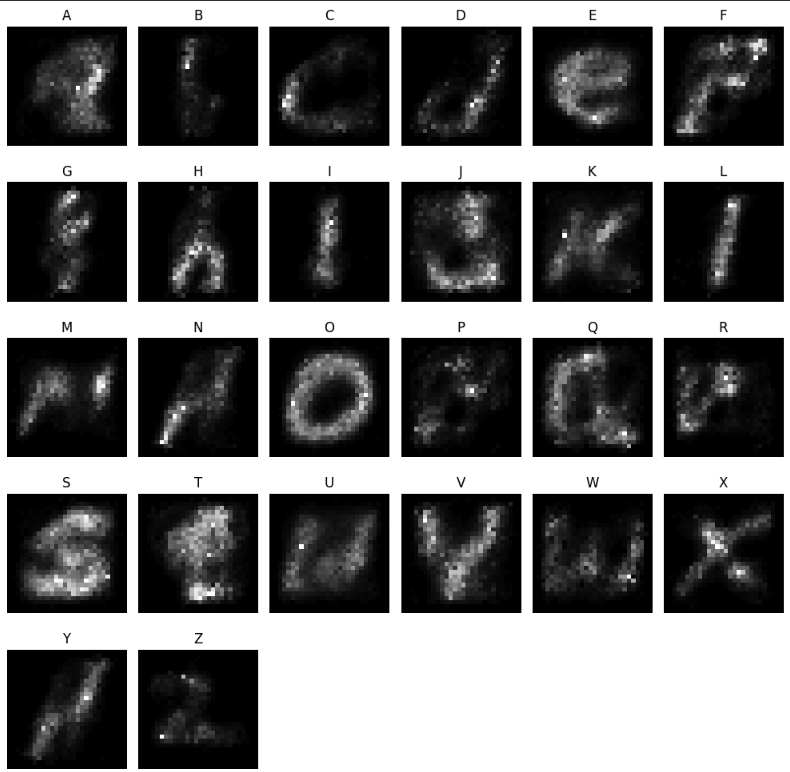

We can recognize some shapes of letters (e, o, s, w, x) but there is still a lot of room of improvement (at least we hope so).

#### Discriminator improvements

In the following step we improved the discriminator in order to achieve higher quality of the individual letters. In theory, since the discriminator will have better ability to decide whether a picture is real or fake, the generator will be forced to learn how to produce better quality samples.

Most of the improvements were taken from the general guidelines that we were given in class `(LeakyReLU)`, the rest is just n improvisation of techniques that proved helpful in our last assignment `(dropout)`



In [ ]:
latent_dim = 32

def build_generator():
    latent_input = Input(shape=(latent_dim,))
    label_input = Input(shape=(num_classes,))

    x = Concatenate()([latent_input, label_input])

    x = Dense(100, activation="relu", kernel_initializer="he_normal")(x)
    x = Dense(150, activation="relu", kernel_initializer="he_normal")(x)

    x = Dense(28 * 28, activation="sigmoid")(x)
    generator_output = layers.Reshape((28, 28))(x)

    return tf.keras.Model([latent_input, label_input], generator_output)


def build_discriminator():
    image_input = Input(shape=(28, 28))
    label_input = Input(shape=(num_classes,))
    flat_image = Flatten()(image_input)

    x = Concatenate()([flat_image, label_input])

    x = Dense(1024, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(512, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    x = Dense(256, kernel_initializer="he_normal")(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dropout(0.3)(x)

    real_or_fake = Dense(1, activation="sigmoid")(x)

    return Model([image_input, label_input], real_or_fake)


generator = build_generator()
discriminator = build_discriminator()

# CGAN
cgan = CGAN(discriminator, generator, latent_dim=latent_dim, num_classes=num_classes)
cgan.compile(
    d_optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    g_optimizer=keras.optimizers.RMSprop(learning_rate=0.005), # g_optimizer=keras.optimizers.RMSprop(learning_rate=0.002),
    loss_fn=keras.losses.BinaryCrossentropy(),
)

cgan.fit(X, y_train, epochs=20)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - d_loss: 0.5336 - g_loss: 2.2035
Epoch 2/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5454 - g_loss: 1.5183
Epoch 3/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5423 - g_loss: 1.4729
Epoch 4/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5387 - g_loss: 1.4415
Epoch 5/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5330 - g_loss: 1.4638
Epoch 6/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5225 - g_loss: 1.5148
Epoch 7/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.5060 - g_loss: 1.6186
Epoch 8/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.4939 - g_loss: 1.6654
Epoch 9/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.4776 - g_loss: 1.7785
Epoch 10/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.4710 - g_loss: 1.8409
Epoch 11/20
2775/2775 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - d_loss: 0.4602 - g_loss: 1.9067
Epoch 12/20
2775/2775 ━━━━━━━

After training the model with the improved discriminator we can see a significant improvement in the quality of individual letters:

**Letters after 20 epochs:**

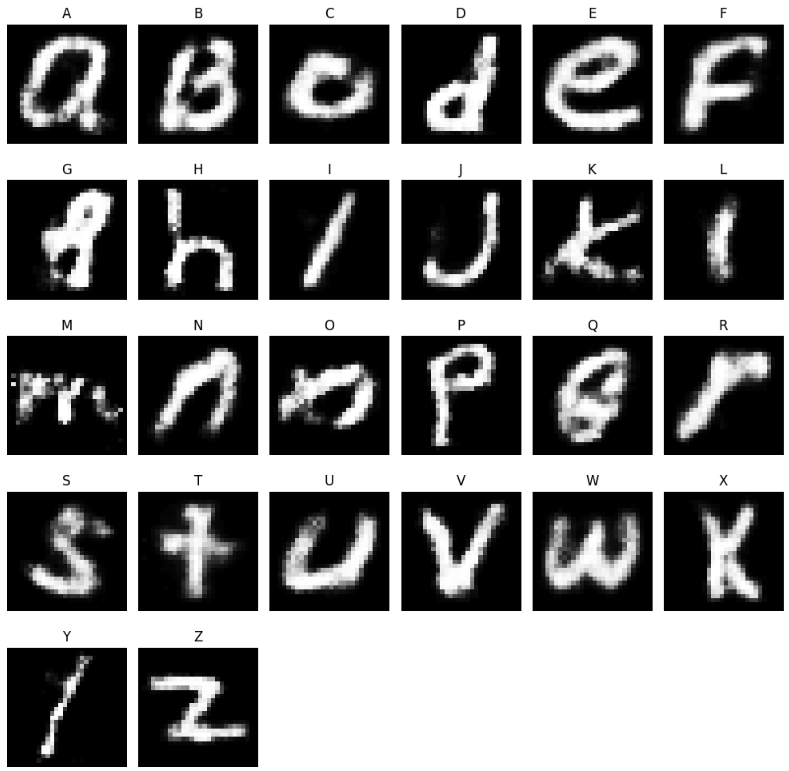

What is an interesting fact to mention is that even though the loss of the generator is higher than of the generator above, the results are way better.

When we look at the loss of the generator in each epoch, we can see that it first goes down to aroun 1.4 and then rises back up to aroud 2.4 at epoch 20 (we tried more epochs which results in more loss and therefore the quality gets worse but what we want to try is to see how the rresult will look when we end at some earlier epoch with lower loss)

We tried to end on epoch 7 and observed that the quality is not as good as to when we let the model learn for 20 epochs. This means that even though the generator has a bigger loss with more epochs it is still beneficial as it improves its writing skills over longer time.

**Letters after 7 epochs:**

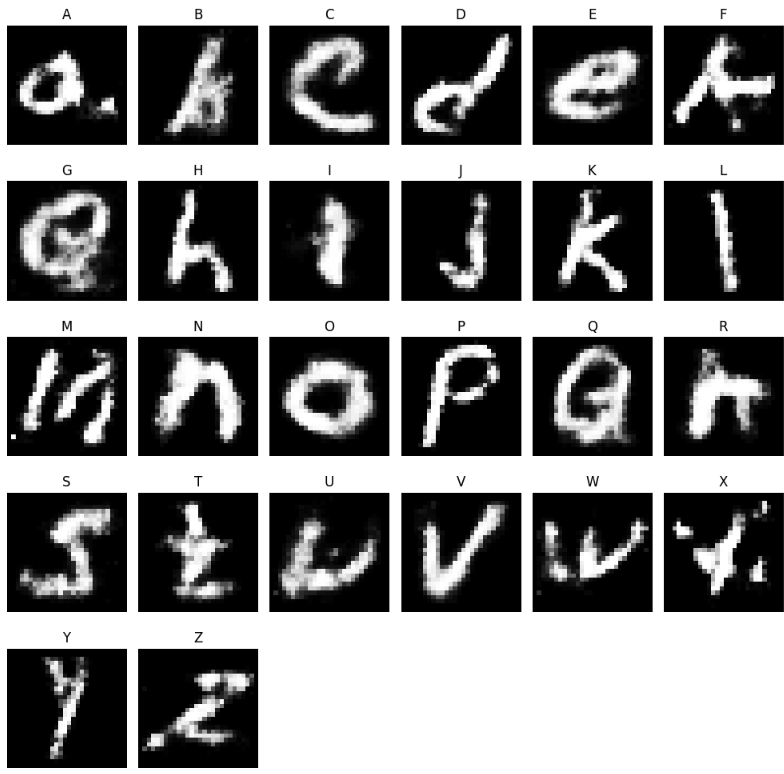

#### Generator improvements

In order to get even better performance from our generator, we wanted to improve it in a similar way as we improved the discriminator, however no matter what upgrades. we tried, we ended with mode collapse. We tried adding noise to the real images to make it harder for the discriminator to identify wich image is the fake one but without success.

These are some of the generator improvements we tried:

- Adding LeakyReLU activation function in between the dense layers
- Adding Batch Normalization
- More than 2 dense layers with more neurons in each layer

We came up with a conclusion that by trying to improve the generator the generator might get **too good** too quick and therefore it is easy for the discriminator to recognize which of the images are fake (as was mentioned in one of the steps of mode collapse in the [5. Generative Adversarial Networks](https://via.itslearning.com/ContentArea/ContentArea.aspx?LocationID=33227&LocationType=1))



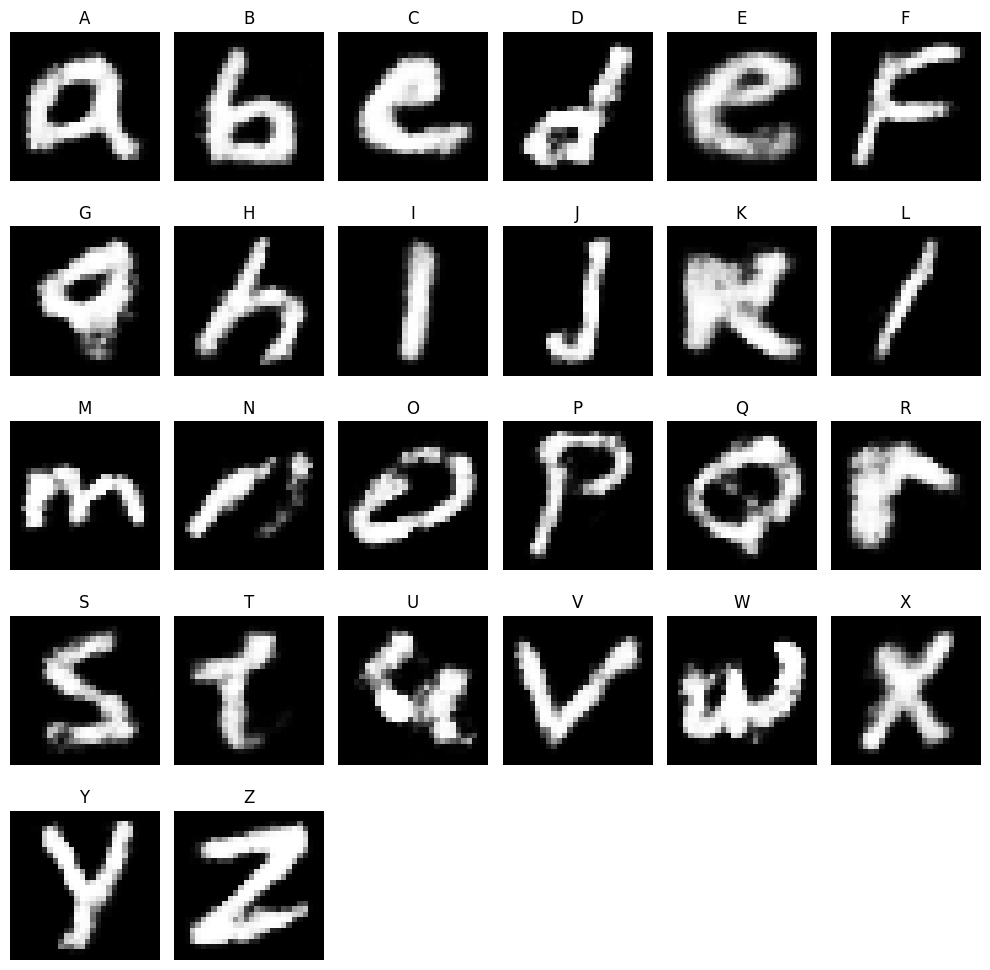

In [ ]:
# Define a function to generate an image for a given letter (class index)
def generate_letter(generator, letter_index, latent_dim):
    # 1. Generate a random latent vector
    random_latent_vector = tf.random.normal(shape=(1, latent_dim))

    # 2. Create a one-hot encoded label for the letter (e.g., 'A' -> index 0)
    label = tf.one_hot([letter_index], num_classes)

    # 3. Generate the image using the generator
    generated_image = generator([random_latent_vector, label])

    # 4. Reshape the generated image
    generated_image = generated_image.numpy().reshape(28, 28)

    return generated_image


# Generate all letters (A-Z) in a grid
def plot_all_letters(generator, latent_dim):
    plt.figure(figsize=(10, 10))  # Create a figure for 26 subplots (5x6 grid)

    for i in range(26):
        plt.subplot(5, 6, i + 1)  # Create a 5x6 grid of subplots
        generated_image = generate_letter(
            generator, letter_index=i, latent_dim=latent_dim
        )
        plt.imshow(generated_image, cmap="gray")
        plt.title(chr(i + ord("A")))  # Convert index back to letter (A, B, C, etc.)
        plt.axis("off")  # Turn off axis labels for a cleaner look

    plt.tight_layout()  # Adjust subplots to fit into the figure area
    plt.show()


# Alphabet according to the generator 🤖
plot_all_letters(generator, latent_dim)

In [ ]:
def plot_string(string, generator, latent_dim):
    plt.figure(figsize=(15, 5))
    string = string.upper()

    for i, letter in enumerate(string):
        plt.subplot(1, len(string), i + 1)
        generated_image = generate_letter(
            generator, letter_index=ord(letter) - ord("A"), latent_dim=latent_dim
        )
        plt.subplots_adjust(wspace=0, hspace=0)
        plt.imshow(generated_image, cmap="gray_r")
        # plt.title(letter) # can be removed for the final output (before handing in)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

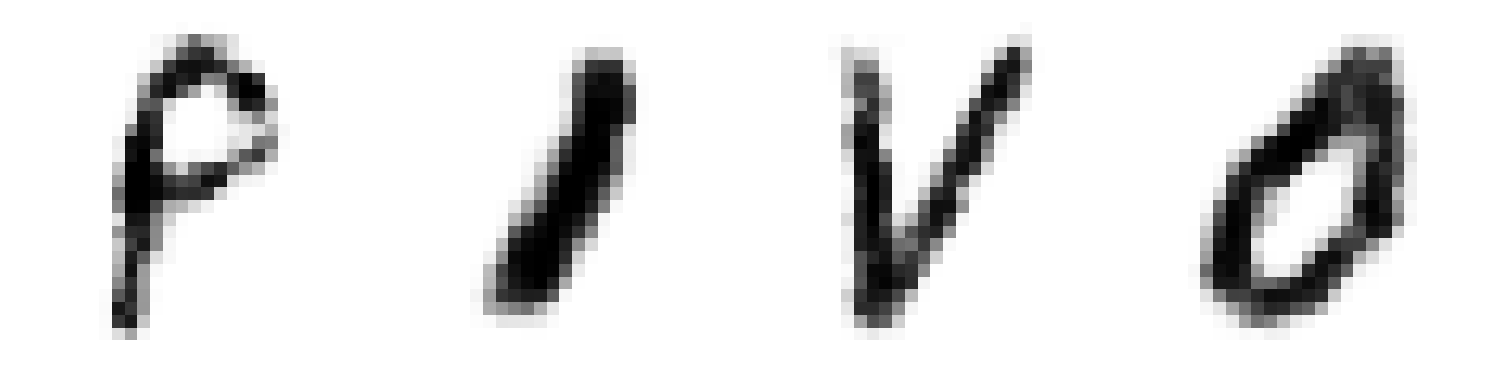

In [ ]:
plot_string("pivo", generator, latent_dim)

~ Because if you ever need to know one Czech or Slovak word, it's this one.

## Interesting figures

We analyzed the dataset after generating the same letter multiple times, we found out that a reason why GCAN struggle to generate some letters is the quality of the dataset where lowercase and capital case letters are combined in one label.

When the letters look similar in both variants, it doesn't causes any problems - in cases like A/a, E/e, G/g/, Q/q generator struggle to stick with either the lowercase or upper case variant.

To improve we would suggest using *EMNIST ByClass* which contains labels for all letters or *EMNIST Balanced* which extends the dataset by the labels for letters that has different variants.

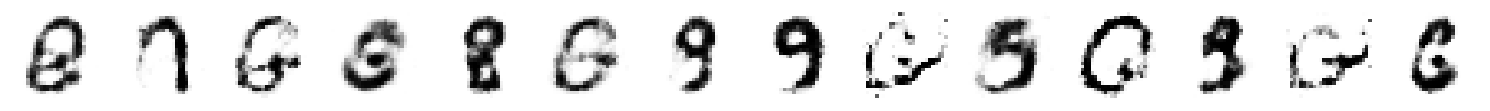

In [ ]:
plot_string("gggggggggggggg", generator, latent_dim)

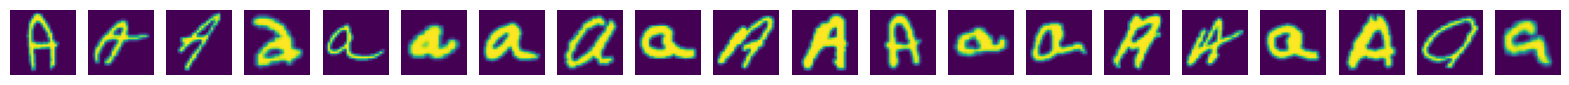

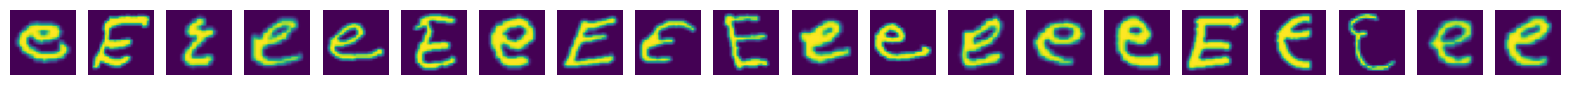

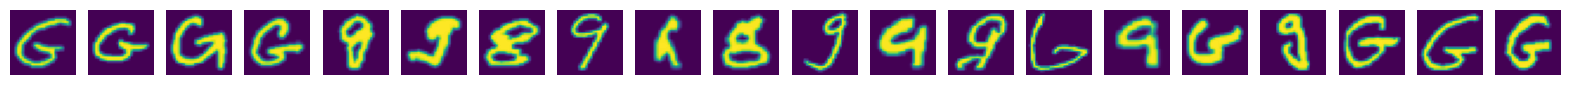

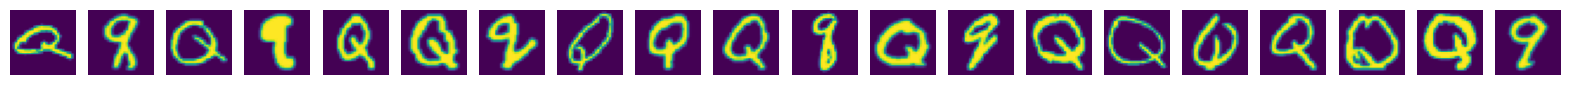

In [ ]:
def plot_random_samples(X, y, label_index, num_samples=20):
    # Find all indices where the label is 'A' (label_index 0 for 'A')
    label_indices = np.where(np.argmax(y, axis=1) == label_index)[0]

    # Randomly choose 20 samples from those indices
    random_indices = np.random.choice(label_indices, num_samples, replace=False)

    # Plottting
    fig, axes = plt.subplots(1, num_samples, figsize=(20, 20))
    for i, ax in enumerate(axes):
        ax.imshow(X[random_indices[i]])
        ax.axis("off")

    plt.show()

plot_random_samples(X_train, y_train, label_index=0, num_samples=20) #A/a
plot_random_samples(X_train, y_train, label_index=4, num_samples=20) #E/e
plot_random_samples(X_train, y_train, label_index=6, num_samples=20) #G/g
plot_random_samples(X_train, y_train, label_index=16, num_samples=20) #Q/q
